<a href="https://colab.research.google.com/github/gigihArmy/hissa_tes_teknis/blob/main/hissa_tes_teknis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Nama: Gigih Army Buana Baliputra

## Dataset Source (Dummy Dataset)

In [5]:
#dummy dataset
import pandas as pd
import numpy as np

#kolom tanggal dan ticker
dates = pd.date_range('2026-01-01', periods=50)
tickers = ['BBRI', 'BIRD', 'GIAA', 'ISAT', 'JPFA', 'KAEF', 'KLBF']

#dataframe
df = pd.DataFrame({'Date': dates,
                  'Ticker': np.random.choice(tickers, 50),
                  'EPS': np.random.normal(5,2,50),
                  'Book_Value': np.random.normal(50,10,50)
                  })

df.head()

,Date,Ticker,EPS,Book_Value
0,2026-01-01,BBRI,4.528627,49.120473
1,2026-01-02,KLBF,4.947658,44.759263
2,2026-01-03,ISAT,5.276377,56.798820
3,2026-01-04,ISAT,8.261783,54.218472
4,2026-01-05,BBRI,4.661040,63.806738


In [6]:
#tambahkan EPS minus secara acak
df.loc[np.random.choice(df.index, 8), 'EPS'] *= -1

#tambahkan baris NaN secara random
df.loc[np.random.choice(df.index, 5), 'EPS'] = np.nan
df.loc[np.random.choice(df.index, 3), 'Book_Value'] = np.nan
df.loc[np.random.choice(df.index, 3), 'Date'] = np.nan
df.loc[np.random.choice(df.index, 2), 'Ticker'] = np.nan

df.to_csv('financial_data.csv')

## Data Cleansing

In [24]:
df = pd.read_csv('financial_data.csv')

#cek df kosong
print('Data Shape\n', df.shape)
print('\nCek Nilai NaN\n', df.isnull().sum())

Data Shape
 (50, 5)

Cek Nilai NaN
 Unnamed: 0    0
Date          3
Ticker        2
EPS           5
Book_Value    3
dtype: int64


In [25]:
#hapus baris NaN pada kolom ticker dan tanggal
#karena tidak mungkin dilakukan imputasi karena sensitif
df = df.dropna(subset=['Date', 'Ticker'])

print('Data Shape\n', df.shape)
print('\nCek Nilai NaN\n', df.isnull().sum())

Data Shape
 (46, 5)

Cek Nilai NaN
 Unnamed: 0    0
Date          0
Ticker        0
EPS           5
Book_Value    3
dtype: int64


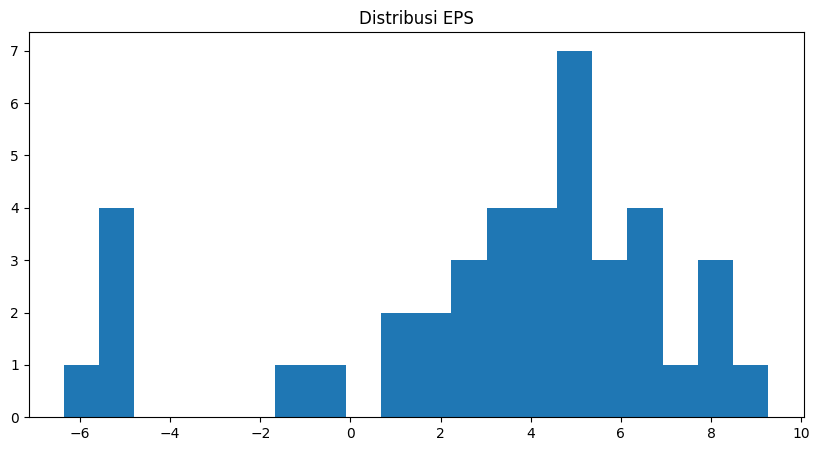

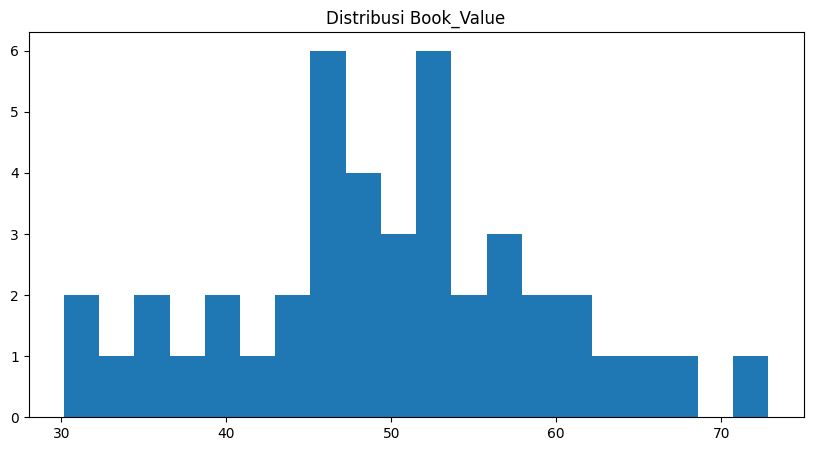

In [26]:
import matplotlib.pyplot as plt

def plot_distribution(df, column):
  plt.figure(figsize=(10,5))
  plt.hist(df[column], bins=20)
  plt.title(f'Distribusi {column}')
  plt.show()

#cek distribusi nilai EPS dan Book Value
plot_distribution(df, 'EPS')
plot_distribution(df, 'Book_Value')

In [27]:
#imputasi menggunakan median pada kolom EPS dan Book Value karena terlihat ada outlier
df['EPS'] = df.groupby('Ticker')['EPS'].transform(lambda x: x.fillna(x.median()))
df['Book_Value'] = df.groupby('Ticker')['Book_Value'].transform(lambda x: x.fillna(x.median()))

print('Data Shape\n', df.shape)
print('\nCek Nilai NaN\n', df.isnull().sum())

Data Shape
 (46, 5)

Cek Nilai NaN
 Unnamed: 0    0
Date          0
Ticker        0
EPS           0
Book_Value    0
dtype: int64


## Kalkulasi Kolom Graham Bell

In [30]:
#kolom graham number
def graham_number(df):
  df['Graham_Number'] = 0 #nilai default
  condition = df['EPS'] > 0

  df.loc[condition, 'Graham_Number'] = np.sqrt(22.5 * df['EPS'] * df['Book_Value'])
  return df

graham_number(df)
df.head()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_2283/1355992994.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 70.74663836  69.63984646 100.39262024  81.80238245  79.23531343
  42.99261123  71.86581361  43.47718992  50.01459785  84.25279883
  68.41537456  67.90507211  34.30460008  77.3601802   56.6909086
  83.60971556  83.42186431  76.3721497  100.97933135  78.57060055
  52.34049246  63.42247391  61.58153175  50.40378455  62.87723603
 103.12377569  54.14222835  98.96598511  86.79201906  68.06691324
  62.70579538  91.07881879  80.7321761   62.19884241  70.70856103
  93.36180878  29.02765333 105.54178002]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[condition, 'Graham_Number'] = np.sqrt(22.5 * df['EPS'] * df['B

,Unnamed: 0,Date,Ticker,EPS,Book_Value,Graham_Number
0,0,2026-01-01,BBRI,4.528627,49.120473,70.746638
1,1,2026-01-02,KLBF,4.947658,43.564571,69.639846
2,2,2026-01-03,ISAT,-5.276377,56.798820,0.000000
3,3,2026-01-04,ISAT,8.261783,54.218472,100.392620
4,4,2026-01-05,BBRI,4.661040,63.806738,81.802382


## Visualisasi

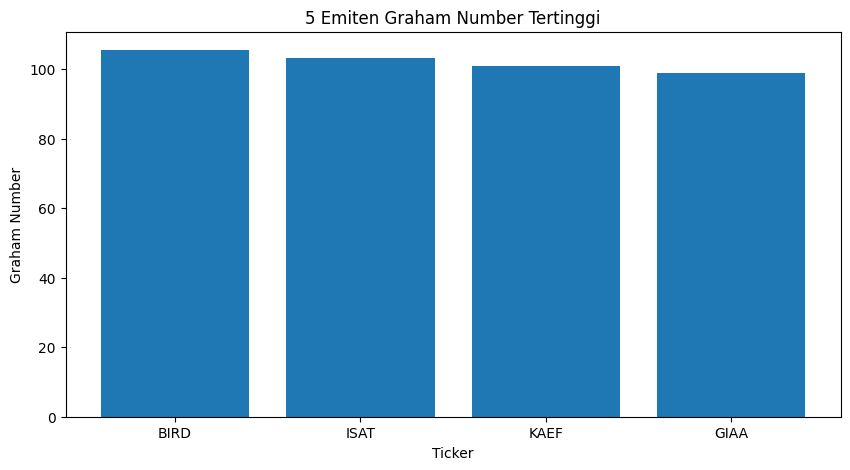

In [32]:
#membandingkan 5 emiten Graham Number Tertinggi
plt.figure(figsize=(10,5))
plt.bar(df.sort_values('Graham_Number', ascending=False).head()['Ticker'], df.sort_values('Graham_Number', ascending=False).head()['Graham_Number'])
plt.title('5 Emiten Graham Number Tertinggi')
plt.xlabel('Ticker')
plt.ylabel('Graham Number')
plt.show()